<a href="https://colab.research.google.com/github/def-himani/NYU/blob/main/qmf/historical_volatility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# May need to run this first since Colab does not provide arch automatically
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 18.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from arch import arch_model
from datetime import datetime, timedelta

### Historical Volatility Calculation Module by Pippa :)

Pulls AAPL daily data from yfinance and computes historical volatility using rolling
close-to-close, EWMA, and GARCH(1,1) methods.

Requirements:

``yfinance numpy pandas matplotlib arch``

Usage:
```
from historical_volatility import VolatilityCalculator
calc = VolatilityCalculator(ticker="AAPL", lookback_years=1)
results = calc.compute(method="all", window=30)
calc.save_csv(results, "aapl_vol.csv")
calc.plot(results)
```



In [3]:
class VolatilityCalculator:
    """
    Compute historical volatility for a given ticker using multiple methods.

    Params:
    ticker: str
        Stock ticker symbol (default "AAPL")
    lookback_years: int or float
        Number of years of daily data to pull (default 1)
    """

    TRADING_DAYS_PER_YEAR = 252

    def __init__(self, ticker: str = "AAPL", lookback_years: float = 1):
        self.ticker = ticker.upper()
        self.lookback_years = lookback_years
        self.prices, self.log_returns = self._fetch_data()

    # DATA ------------------------------------------------------------------
    def _fetch_data(self) -> tuple[pd.Series, pd.Series]:
        """Pull adjusted close prices and compute log returns """
        end = datetime.today()
        start = end - timedelta(days=int(self.lookback_years * 365) + 30) # extra 30 day buffer so rolling windows aren't starting with NaN
        df = yf.download(self.ticker, start=start, end=end, auto_adjust=True)
        if df.empty:
            raise ValueError(f"No data return for {self.ticker}")
        prices = df["Close"].squeeze()
        log_returns = np.log(prices / prices.shift(1)).dropna()
        return prices, log_returns

    # Method 1: Rolling close-to-close ---------------------------------------
    def rolling_volatility(self, window: int = 30) -> pd.Series:
        """
        Rolling standard deviation of log returns, annualized

        Params:
        window: int
            Number of trading days in the rolling window (default:30)
        """
        vol = self.log_returns.rolling(window=window).std() * np.sqrt(self.TRADING_DAYS_PER_YEAR)
        vol.name = f"Rolling_{window}d"
        return vol.dropna()

    # Method 2: EWMA ---------------------------------------------------------
    def ewma_volatility(self, decay: float = 0.94) -> pd.Series:
        """
        Exponentially weighted moving average volatility, annualized.

        Params:
        decay: float
            Decay factor lambda (default 0.94)
        """
        returns = self.log_returns.values
        n = len(returns)
        variance = np.zeros(n)
        # seed with first return squared
        variance[0] = returns[0] ** 2
        for t in range(1,n):
            variance[t] = decay*variance[t-1] + (1-decay)*returns[t-1]**2
        vol = pd.Series(np.sqrt(variance)*np.sqrt(self.TRADING_DAYS_PER_YEAR), index=self.log_returns.index, name="EWMA_lambda{decay}")
        return vol

    # Method 3: GARCH(1,1)
    def garch_volatility(self) -> tuple[pd.Series, dict]:
        """
        Fit a GARCH(1,1) model and return conditional volatility series (annualized) plus fitted parameters.

        Returns:
        vol: pd.Series
            Annualized conditional volatility
        params: dict
            Fitted ω, α, β and sum α+β
        """
        scaled_returns = self.log_returns * 100
        model = arch_model(scaled_returns, vol="Garch", p=1, q=1, dist="normal")
        result = model.fit(disp="off")
        daily_vol_pct = result.conditional_volatility
        vol = (daily_vol_pct/100) * np.sqrt(self.TRADING_DAYS_PER_YEAR)
        vol.name = "GARCH(1,1)"
        params = {
            "omega": result.params["omega"],
            "alpha": result.params["alpha[1]"],
            "beta": result.params["beta[1]"],
            "persistence": result.params["alpha[1]"] + result.params["beta[1]"],
        }
        return vol, params

    # ----------------------------------------------------------------------
    # Unified compute method
    def compute(self, method: str = "all", window: int = 30, ewma_decay: float = 0.94) -> pd.DataFrame:
        """
        Compute volatility using one or all methods

        Params:
        method: str
            One of "rolling", "ewma", "garch", or "all" (default)
        window: int
            Rolling window size in trading days, used by rolling method
        ewma_decay: float
            EWMA decay factor lambda

        Returns:
            pd.DataFrame - DataFrame indexed by date with a column per method
        """
        series = {}
        if method in ("rolling", "all"):
            series["Rolling"] = self.rolling_volatility(window=window)
        if method in ("ewma", "all"):
            series["EWMA"] = self.ewma_volatility(decay=ewma_decay)
        if method in ("garch", "all"):
            garch_vol, garch_params = self.garch_volatility()
            series["GARCH(1,1)"] = garch_vol
            print("GARCH(1,1) fit parameters: ")
            for k, v in garch_params.items():
                print(f"{k}: {v:.6f}")
        df = pd.DataFrame(series)
        df = df.dropna(how="all")
        return df

    # CSV Export ---------------------------------------------------------------
    def save_csv(self, df: pd.DataFrame, filename: str = "historical_volatility.csv"):
        """Save the volatility DataFrame to CSV."""
        df.to_csv(filename, float_format="%.6f")
        print(f"Saved to {filename}  ({len(df)} rows)")

    # Visualization ------------------------------------------------------------
    def plot(
          self,
          df: pd.DataFrame,
          title: str = "Historical Volatility",
          figsize: tuple = (14, 6),
          start_date: str | None = None,
          end_date: str | None = None,
          tick_interval: int=3
        ):
        """
        Plot one or more volatility series.

        Params
        df: pd.DataFrame
            Output of compute().
        title: str
            Chart title.
        figsize: tuple
            Figure size.
        start_date, end_date : str or None
            Optional date strings ("YYYY-MM-DD") to zoom into a sub-period.
        """
        plot_df = df.copy()
        if start_date:
            plot_df = plot_df.loc[start_date:]
        if end_date:
            plot_df = plot_df.loc[:end_date]

        fig, ax = plt.subplots(figsize=figsize)
        for col in plot_df.columns:
            ax.plot(plot_df.index, plot_df[col], label=col, linewidth=1.4)

        ax.set_title(title, fontsize=14, fontweight="bold")
        ax.set_ylabel("Annualized Volatility")
        ax.set_xlabel("Date")
        ax.legend(loc="upper left")
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=tick_interval))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
        fig.autofmt_xdate()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [4]:
calc = VolatilityCalculator(ticker="AAPL", lookback_years=1)

[*********************100%***********************]  1 of 1 completed


In [5]:
# Compute with all three methods, 30 day window
results = calc.compute(method="all", window=30, ewma_decay=0.94)

GARCH(1,1) fit parameters: 
omega: 0.194069
alpha: 0.015627
beta: 0.887210
persistence: 0.902838


In [6]:
calc.save_csv(results, "aapl_historical_volatility.csv")

Saved to aapl_historical_volatility.csv  (271 rows)


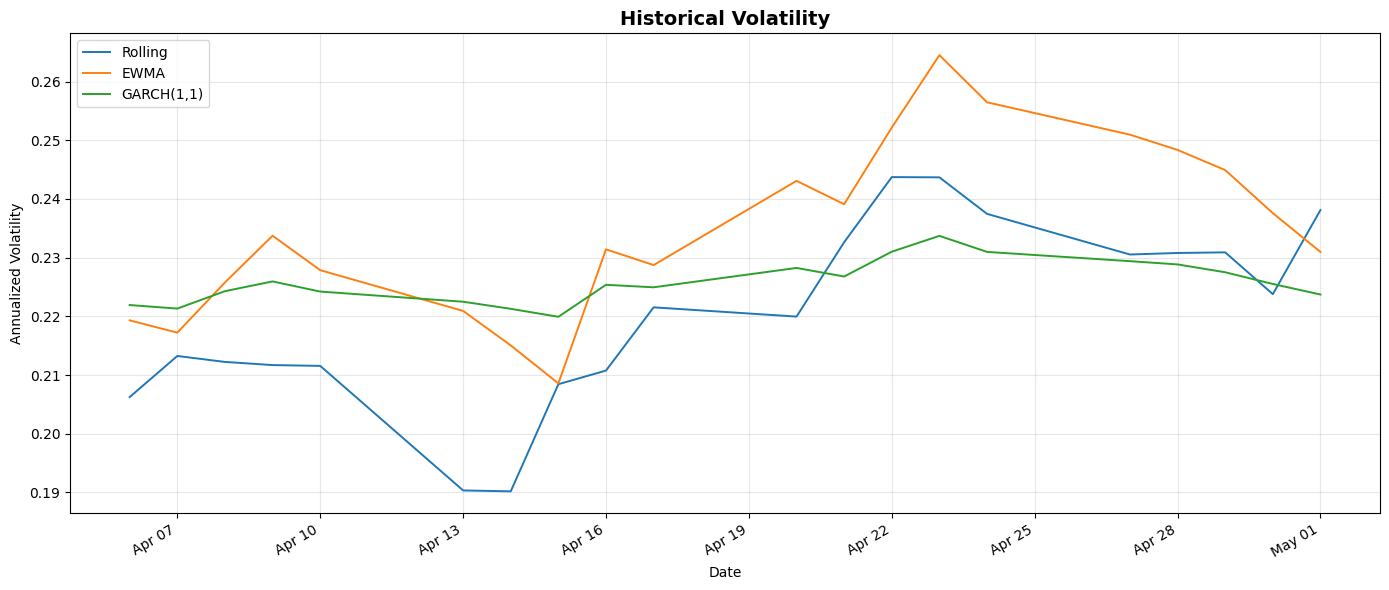

In [7]:
calc.plot(results, start_date="2026-04-03", end_date="2026-05-03")

### Some explanations

#### Rolling Window
For a window of size $n$:

$$\sigma_t = \left( \frac{1}{n-1} \sum^{n-1}_{i=0}(r_{t-i}-\bar{r})^2 \right)^{1/2}$$

where $r_t=ln(\frac{P_t}{P_{t-1}})$ is the log return and $\bar{r}$ is the mean return over the rolling window.

The daily volatility is multiplied by $\sqrt{252}$ to get annualized volatility. Expressed in variance: $\sigma^2_{annual}=252 \times \sigma^2_{daily}$.

Every return in the window has equal weight $\frac{1}{n-1}$, and returns outside of the window have zero weight. The line looks jagged because a large return coming off the back of the window might would cause a sudden jump despite nothing having happened on this particular day.



In [8]:
results_rolling = calc.compute(method="rolling", window=30)

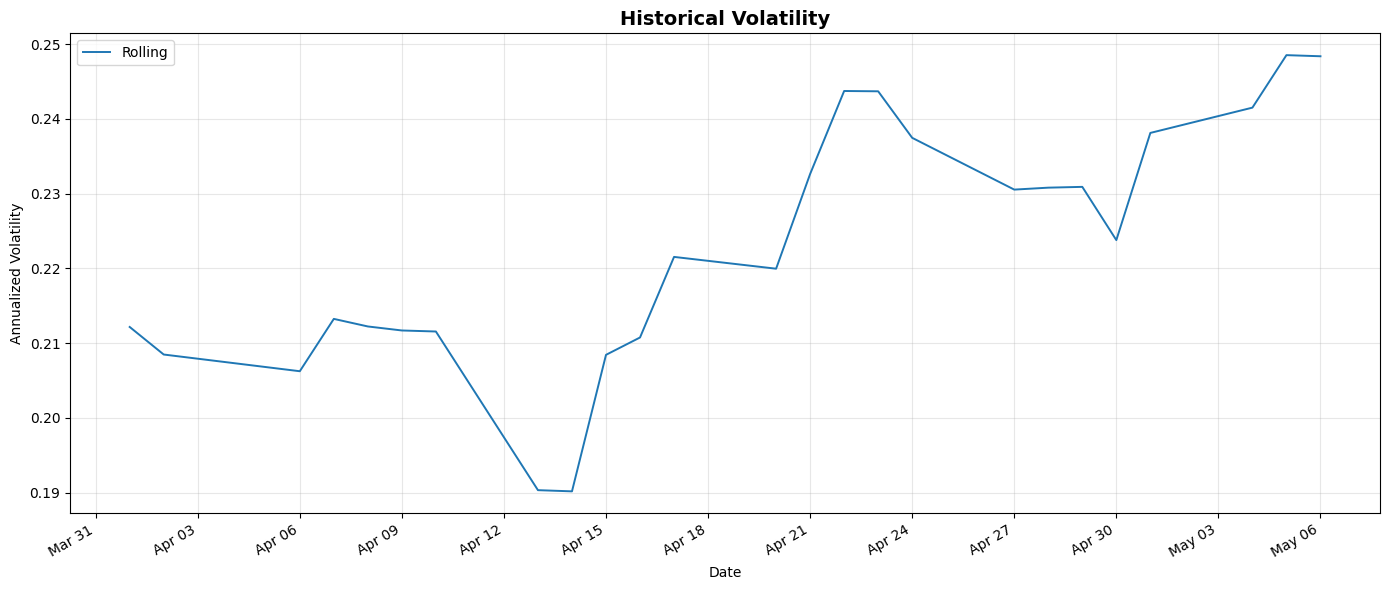

In [9]:
calc.plot(results_rolling, start_date="2026-04-01")

#### EWMA

EWMA gives exponentially decaying weights to older returns:
$$\sigma_t^2=\lambda \cdot \sigma^2_{t-1} + (1-\lambda) \cdot r^2_{t-1}$$
Expressed recursively:
$$\sigma^2_t=(1-\lambda)\sum^\infty_{i=1}\lambda^{i-1} \cdot r^2_{t-i}$$

Notice there is no cutoff on the window because old returns just gradually fade out. Also notice that there is no subtraction of the mean because EWMA assumes $\bar{r}=0$ for daily returns.

Visually, we can discern how EWMA reacts fastest to new information with higher spikes. These represent recent events.

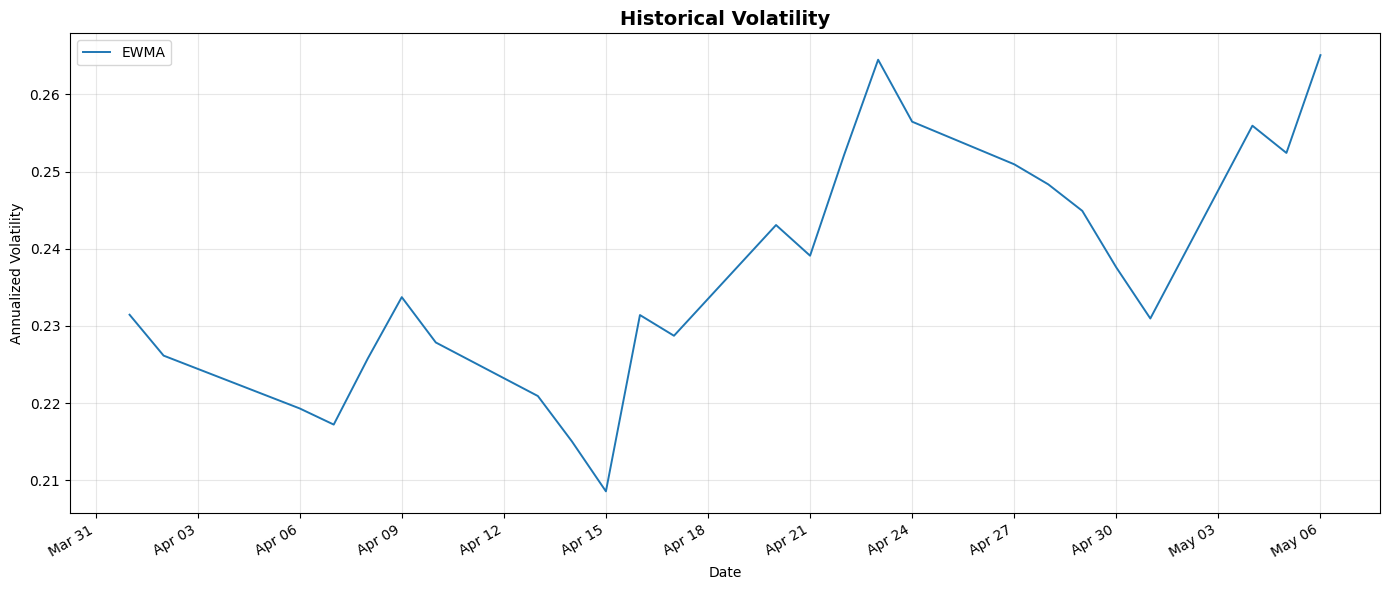

In [10]:
results_ewma = calc.compute(method="ewma", ewma_decay=0.94)
calc.plot(results_ewma, start_date="2026-04-01")

#### GARCH(1,1)

GARCH(1,1) is essentially a generalization of EWMA which adds a mean reversion term:

$$\sigma^2_t=\omega+\alpha \cdot r^2_{t-1}+ \beta \cdot \sigma^2_{t-1}$$

EWMA is a special case of GARCH where $\omega=0$ and $\alpha+\beta=1$, where $\alpha=1-\lambda$ and $\beta=\lambda$. The $\omega$ term pulls the variance toward a long-run average, and EWMA sets this to 0, which is why EWMA is jagged compared to GARCH. The $\alpha \cdot r^2_{t-1}$ term represents the reaction to new information and $\beta \cdot \sigma^2_{t-1}$ represents the persistence of previous volatility.

The long-run variance in GARCH is $$\bar{\sigma}^2=\frac{\omega}{1-\alpha-\beta}$$

GARCH estimates the parameters from the data using maximum likelihood while EWMA often just uses the assumption $\lambda=0.94$. This is why GARCH has the smoothest line.

GARCH(1,1) fit parameters: 
omega: 0.194069
alpha: 0.015627
beta: 0.887210
persistence: 0.902838


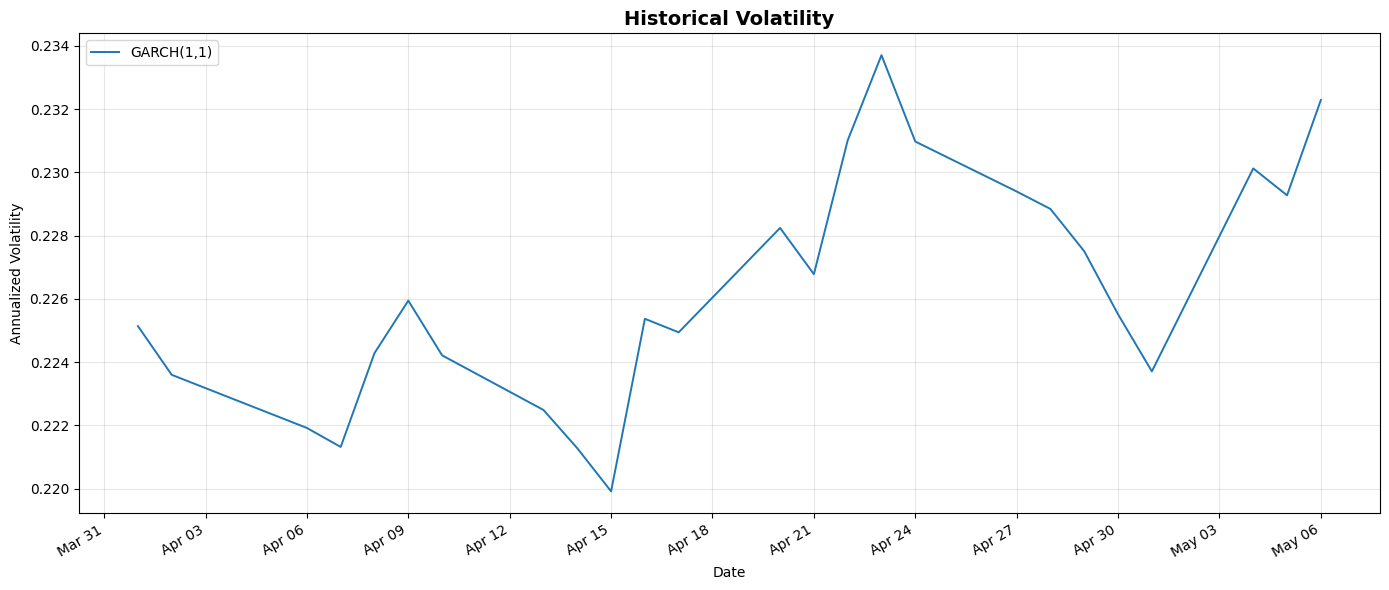

In [11]:
results_garch = calc.compute(method="garch")
calc.plot(results_garch, start_date="2026-04-01")